# Fraud Detection Project

This notebook implements a fraud detection pipeline using Python.  
It covers:
- Data loading and exploration  
- Preprocessing with ColumnTransformer  
- Model training (Logistic Regression)  
- Evaluation with classification metrics  
- Saving the trained model  

## 0. Environment Information

To ensure reproducibility and avoid version mismatches, we first check the Python version and operating system details.

In [2]:
# Basic setup
import sys, os, platform, time

print("Python version:", sys.version)
print("Platform:", platform.platform())

Python version: 3.12.3 | packaged by conda-forge | (main, Apr 15 2024, 18:20:11) [MSC v.1938 64 bit (AMD64)]
Platform: Windows-11-10.0.26200-SP0


## 1. Import Libraries

We import the essential Python libraries for data analysis, numerical computations, and visualization.

In [3]:
# Core libraries for data analysis and visualization
import pandas as pd        # data manipulation and analysis
import numpy as np         # numerical computations
import matplotlib.pyplot as plt  # plotting
import seaborn as sns      # statistical data visualization

## 2. Configuration

We suppress unnecessary warnings for cleaner output and set a consistent visualization style with Seaborn.

In [4]:
# Configuration: cleaner output and visualization style
import warnings
warnings.filterwarnings("ignore")   # hide warnings
sns.set(style="whitegrid")          # set Seaborn style

## 3. Load Dataset

We load the fraud detection dataset into a Pandas DataFrame for further exploration and preprocessing.

In [5]:
# Load the dataset
df = pd.read_csv("../data/AIML Dataset.csv")

## 4. Initial Data Exploration

We start by previewing the first few rows of the dataset to get an initial understanding of its structure.

In [6]:
# Preview the first 5 rows of the dataset
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## 5. Dataset Overview

We check the dataset structure, column data types, and the number of non-null values using `df.info()`.

In [7]:
# Display dataset information: column types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


## 6. Column Names

We list all the column names in the dataset to understand the available features.

In [8]:
# List all column names
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

## 7. Target Variable Distribution

We examine the distribution of the target variable `isFraud` to check for class imbalance.

In [9]:
# Count the occurrences of each class in the target variable
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

## 8. Flagged Fraud Distribution

We check the distribution of the `isFlaggedFraud` variable to see how many transactions are flagged as fraud by the system.

In [10]:
# Count the occurrences of each class in the flagged fraud variable
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

## 9. Missing Values

We check for missing values in the dataset.  
The result shows the total number of `NaN` values across all columns.

In [11]:
# Count total missing values in the dataset
df.isnull().sum().sum()

0

## 10. Dataset Shape

We check the shape of the dataset to see the number of rows (observations) and columns (features).

In [12]:
# Show dataset shape: (rows, columns)
df.shape

(6362620, 11)

## 11. Fraud Percentage

We calculate the percentage distribution of fraudulent (`isFraud = 1`) and non-fraudulent (`isFraud = 0`) transactions.

In [13]:
# Percentage distribution of fraud vs. non-fraud
df["isFraud"].value_counts(normalize=True) * 100

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

## 12. Transaction Types Distribution

We analyze the distribution of transaction types in two ways:
- A bar chart to visualize the frequency of each type  
- Percentage values to understand their relative proportions

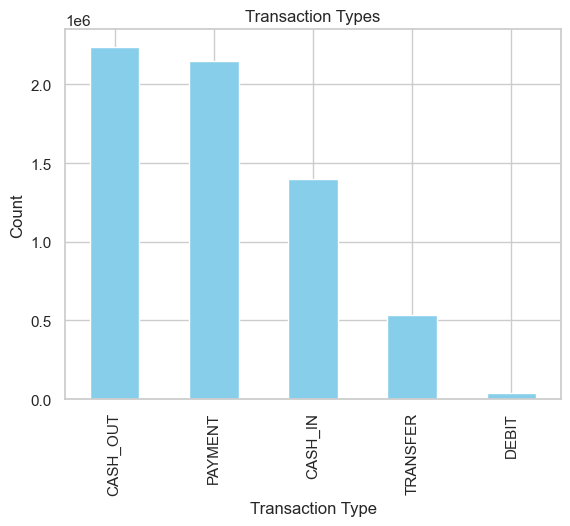

type
CASH_OUT    35.166331
PAYMENT     33.814608
CASH_IN     21.992261
TRANSFER     8.375622
DEBIT        0.651178
Name: proportion, dtype: float64

In [14]:

# Plot distribution of transaction types
df['type'].value_counts().plot(
    kind='bar',
    title='Transaction Types',
    color='skyblue'
)
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.show()

# Show percentages
df['type'].value_counts(normalize=True) * 100

## 13. Fraud Rate by Transaction Type

We calculate and visualize the fraud rate for each transaction type.  
The results are shown both as a bar chart and as percentage values for clearer interpretation.

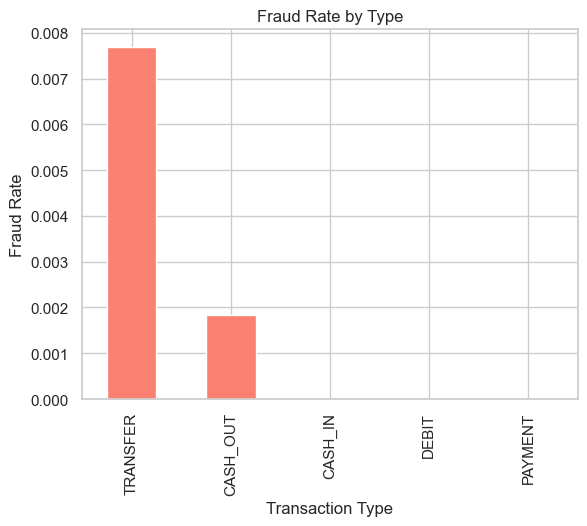

type
TRANSFER    0.768799
CASH_OUT    0.183955
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

In [15]:
# Calculate fraud rate by transaction type
fraud_by_type = df.groupby('type')['isFraud'].mean().sort_values(ascending=False)

# Plot fraud rate by transaction type
fraud_by_type.plot(
    kind='bar',
    title='Fraud Rate by Type',
    color='salmon'
)
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Rate')
plt.show()

# Show fraud rate in percentages
fraud_by_type * 100

## 14. Transaction Amount Summary

We generate descriptive statistics for the `amount` variable to understand the distribution of transaction values.

In [16]:
# Summary statistics of transaction amounts
df['amount'].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int32

## 15. Transaction Amount Distribution (Log Scale)

We plot the distribution of transaction amounts on a log scale to better visualize the highly skewed data.

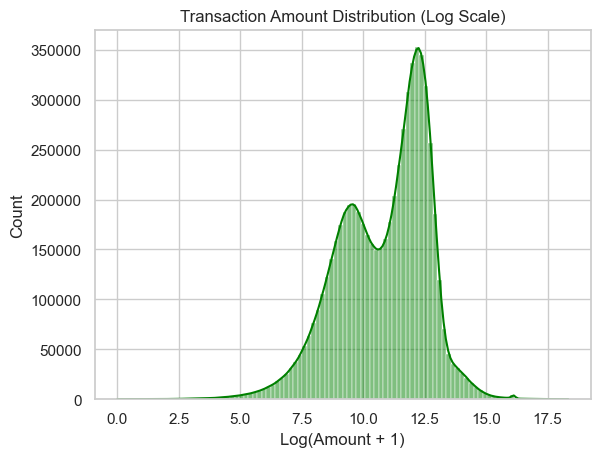

In [17]:
# Plot transaction amount distribution on a log scale
sns.histplot(np.log1p(df['amount']), bins=100, kde=True, color='green')
plt.title('Transaction Amount Distribution (Log Scale)')
plt.xlabel('Log(Amount + 1)')
plt.show()

## 16. Transaction Amount by Fraud Status

We use a boxplot (filtered for transactions under 50k) to compare the distribution of transaction amounts between fraudulent and non-fraudulent cases.

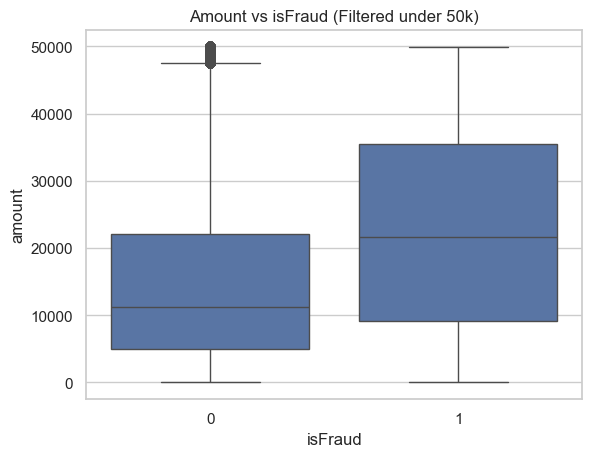

In [18]:
# Boxplot of transaction amount vs fraud status (filtered under 50k)
sns.boxplot(data=df[df['amount'] < 50000], x='isFraud', y='amount')
plt.title('Amount vs isFraud (Filtered under 50k)')
plt.show()

## 17. Feature Engineering: Balance Differences

We create new features that capture the difference in account balances before and after each transaction:
- `balanceDiffOrig` = oldbalanceOrg - newbalanceOrig  
- `balanceDiffDest` = newbalanceDest - oldbalanceDest  

These features may highlight unusual patterns in fraudulent transactions.

In [19]:
# Create new balance difference features
df['balanceDiffOrig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balanceDiffDest'] = df['newbalanceDest'] - df['oldbalanceDest']

## 18. Check Invalid Balance Differences

We check how many cases have a negative `balanceDiffOrig`.  
A negative value would indicate that the origin account balance increased after the transaction, which is logically inconsistent and may signal data quality issues or fraud-related anomalies.

In [20]:
# Count cases with negative origin balance difference
(df['balanceDiffOrig'] < 0).sum()

1399253

## 19. Check Invalid Balance Differences (Destination)

We check how many cases have a negative `balanceDiffDest`.  
A negative value means the destination account balance decreased after the transaction, which is inconsistent with valid money transfers and may highlight anomalies or data issues.

In [21]:
# Count cases with negative destination balance difference
(df['balanceDiffDest'] < 0).sum()

1238864

## 20. Frauds Over Time

We analyze how fraudulent transactions are distributed over time (`step` variable).  
This helps identify if fraud occurs uniformly or in specific periods.

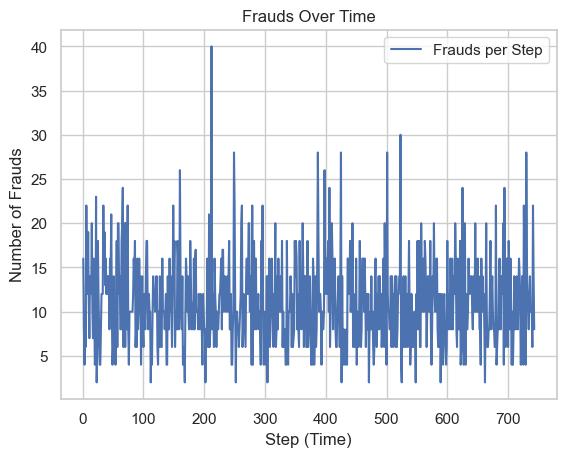

In [22]:
# Plot number of frauds over time (per step)
fraud_per_step = df[df['isFraud'] == 1]['step'].value_counts().sort_index()

plt.plot(fraud_per_step.index, fraud_per_step.values, label='Frauds per Step')
plt.xlabel('Step (Time)')
plt.ylabel('Number of Frauds')
plt.title('Frauds Over Time')
plt.grid(True)
plt.legend()
plt.show()

## 21. Drop Unnecessary Columns

We remove the `step` column since it only represents time steps and is not directly informative for the predictive model.

In [23]:
df.drop(columns='step' ,inplace=True)

## 22. Top Senders by Transaction Count

We identify the top 10 origin accounts (`nameOrig`) with the highest number of transactions.  
This helps reveal whether a small number of accounts dominate the activity, which may indicate automated or suspicious behavior.

In [24]:
top_senders = df['nameOrig'].value_counts().head(10)

### Display Top Senders

In [25]:
top_senders

nameOrig
C1902386530    3
C363736674     3
C545315117     3
C724452879     3
C1784010646    3
C1677795071    3
C1462946854    3
C1999539787    3
C2098525306    3
C400299098     3
Name: count, dtype: int64

## 23. Top Receivers by Transaction Count

We identify the top 10 destination accounts (`nameDest`) with the highest number of transactions.  
This helps us understand whether certain accounts receive disproportionately large volumes of transfers, which may indicate unusual or suspicious patterns.

In [26]:
top_receivers= df['nameDest'].value_counts().head(10)

### Display Top Receivers

In [27]:
top_receivers

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C451111351      99
C1789550256     99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

## 24. Top Fraudulent Senders

We identify the top 10 origin accounts (`nameOrig`) involved in the highest number of fraudulent transactions.  
This helps highlight accounts with repeated fraudulent behavior.

In [28]:
fraud_users = df[df['isFraud']==1] ['nameOrig'].value_counts().head(10)

### Display Top Fraudulent Senders

In [29]:
fraud_users

nameOrig
C1305486145    1
C755286039     1
C973279667     1
C258213312     1
C1640703547    1
C1127265876    1
C317779855     1
C1064034527    1
C1141104763    1
C1966863341    1
Name: count, dtype: int64

## 25. Filter Fraud-Prone Transaction Types

Fraud in this dataset occurs almost exclusively in `TRANSFER` and `CASH_OUT` transactions.  
We create a filtered subset that contains only these two types for further focused analysis.

In [30]:
fraud_types = df[df['type'].isin(['TRANSFER','CASH_OUT'])]

### Distribution of Transaction Types in the Fraud-Prone Subset

In [31]:
fraud_types['type'].value_counts()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

## 26. Fraud Distribution Within TRANSFER and CASH_OUT

We visualize how fraudulent and non-fraudulent transactions are distributed across the two fraud-prone transaction types.

### Analysis
CASH_OUT and TRANSFER behave very differently with respect to fraud:

- Fraud cases tend to appear far more frequently in CASH_OUT transactions.
- TRANSFER transactions also contain fraud, but at a much lower absolute count.
- This pattern aligns with real-world behavior: fraudsters often TRANSFER money from a victim account and immediately CASH_OUT the funds.

This insight will influence the feature engineering and the model interpretation.

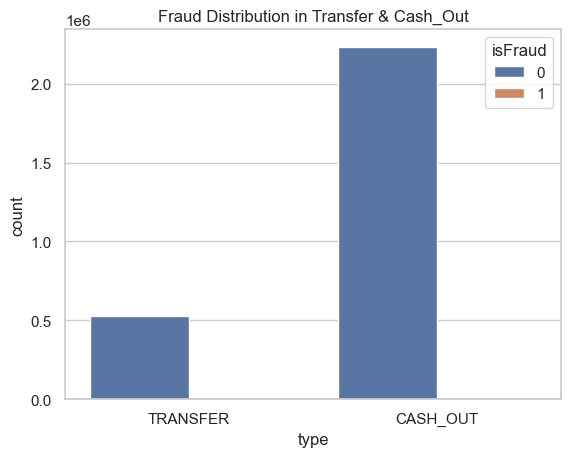

In [32]:
sns.countplot(data=fraud_types, x='type', hue='isFraud')
plt.title('Fraud Distribution in Transfer & Cash_Out')
plt.show()

## 27. Correlation Matrix of Key Numerical Features

We compute the correlation matrix for the main numerical features and the target variable `isFraud` to identify linear relationships that may influence the model.

### Analysis
This correlation matrix helps us understand how each numerical feature relates to the others and to the target variable `isFraud`.

However:
- Fraud detection datasets often show **weak linear correlations**, because fraud patterns tend to be non-linear.
- Therefore, even if correlations with `isFraud` appear low, the features may still be highly informative when combined in a machine-learning model.

We will later examine these relationships in more depth using non-linear models and importance metrics.

In [33]:
corr = df[['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']].corr()

### Display Correlation Matrix

In [34]:
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


## 28. Correlation Heatmap

We visualize the correlation matrix using a heatmap to better understand linear relationships among key numerical features.

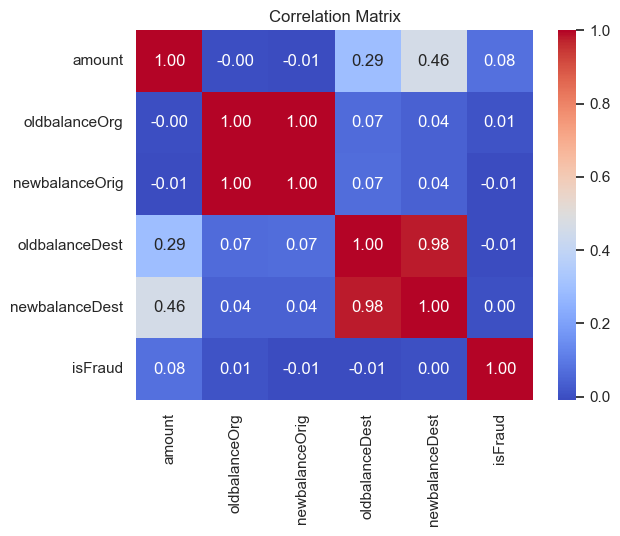

In [35]:
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## 29. Zero Balance After Transaction (Potential Fraud Pattern)

We identify transactions where:
- the origin account had a positive balance before the transaction,
- the new balance became zero after the transaction,
- and the transaction type was either `TRANSFER` or `CASH_OUT`.

This pattern may indicate accounts that are drained completely — a behavior often associated with fraudulent activity.


In [36]:
zero_after_transfer = df[
    (df['oldbalanceOrg'] >0) &
    (df['newbalanceOrig'] == 0) &
    (df['type'].isin(['TRANSFER', 'CASH_OUT']))
    ]

### Count of Zero-Balance After Transaction Cases


In [37]:
len(zero_after_transfer)

1188074

### Preview of Zero-Balance After Transaction Cases

In [38]:
zero_after_transfer.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,2712905.89


### Final Check: Fraud vs Non-Fraud Counts

In [39]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

## 30. Model Preparation: Imports for Machine Learning

We import all the necessary tools for building the fraud detection model, including:
- data splitting,
- preprocessing (scaling and encoding),
- model training (Logistic Regression),
- evaluation metrics,
- and pipeline utilities.

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

## 31. Remove Unnecessary or High-Cardinality Columns

We drop the following columns before modeling:
- `nameOrig` and `nameDest`: high-cardinality identifiers that do not generalize well and would lead to an extremely sparse encoding.
- `isFlaggedFraud`: almost always zero in this dataset and not useful for prediction.

The remaining columns will be used to build the model.

In [41]:
df_model = df.drop(['nameOrig', 'nameDest', 'isFlaggedFraud'], axis=1)

### Preview of df_model After Column Removal

In [42]:
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,181.00,-21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0


## 32. Define Numerical and Categorical Feature Sets

We separate the dataset features into:
- **categorical variables**: to be one-hot encoded  
- **numerical variables**: to be scaled

This structure will be passed into the `ColumnTransformer` for proper preprocessing.

In [43]:
categorical = ['type']
numerical = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

## 33. Define Target Variable (y) and Feature Matrix (X)

We separate the target variable `isFraud` from the feature matrix.  
This is the standard structure required for machine learning models.

In [44]:
y = df_model['isFraud']
X = df_model.drop('isFraud', axis=1)

## 34. Train-Test Split (with Stratification)

We split the dataset into training and testing sets.  
Because the target variable `isFraud` is highly imbalanced, we use `stratify=y` to preserve the fraud ratio in both sets.

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

## 35. Build Preprocessing Pipeline (ColumnTransformer)

We create a preprocessing pipeline using `ColumnTransformer`:
- Numerical features are scaled using `StandardScaler`.
- Categorical features are encoded using `OneHotEncoder` (with `drop='first'` to avoid multicollinearity).
- All other columns are dropped (`remainder='drop'`).

This ensures that the same preprocessing is consistently applied during both training and testing.

In [46]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical),
        ('cat', OneHotEncoder(drop='first'), categorical)
    ],
    remainder= 'drop'
)

## 36. Build the Full Modeling Pipeline

We combine the preprocessing steps and the classifier into a single unified pipeline:
- `prep`: applies scaling to numerical features and one-hot encoding to categorical features.
- `clf`: a Logistic Regression classifier with `class_weight='balanced'` to address the extreme class imbalance.

This ensures that preprocessing and modeling are performed together without data leakage.

In [47]:
pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
])

## 37. Train the Model

We fit the full pipeline (preprocessing + Logistic Regression) on the training data only.  
This ensures that all preprocessing steps (scaling, encoding) are learned strictly from `X_train`, avoiding any information leakage from the test set.


In [48]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['type'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

## 38. Generate Predictions on the Test Set

We use the trained pipeline to generate class predictions (`0` for non-fraud, `1` for fraud) on the test set.

In [49]:
y_pred = pipeline.predict(X_test)

## 39. Classification Report

We evaluate the baseline performance of the model using the classification report.  
This includes precision, recall, f1-score, and support for each class.

In [50]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97   1906322
           1       0.02      0.94      0.04      2464

    accuracy                           0.94   1908786
   macro avg       0.51      0.94      0.51   1908786
weighted avg       1.00      0.94      0.97   1908786



## 40. Confusion Matrix

The confusion matrix helps us understand how the model performs on each class,  
especially the minority fraud class, by showing:
- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)
- True Positives (TP)

In [51]:
confusion_matrix(y_test, y_pred)

array([[1800832,  105490],
       [    142,    2322]], dtype=int64)

## 41. Accuracy Score (for reference only)

We compute the accuracy of the model on the test set.

**Note:**  
Accuracy is not a reliable metric for fraud detection due to extreme class imbalance.  
A model can achieve >99% accuracy simply by predicting all transactions as non-fraud.  
We will rely instead on probability-based metrics such as Precision–Recall AUC.

In [52]:
pipeline.score(X_test, y_test) * 100

94.46601138105581

## 42. Save the Trained Model

We save the full pipeline (preprocessing + classifier) as a `.pkl` file using `joblib`.  
This allows the model to be easily loaded later for inference or deployment.

In [53]:
from pathlib import Path
import joblib

ROOT_DIR = Path().resolve().parents[0]
MODEL_PATH = ROOT_DIR / 'models' / 'fraud_detection_model.pkl'

joblib.dump(pipeline, MODEL_PATH)

['C:\\Users\\ataba\\Desktop\\Files\\VS Code\\fraud-detection-streamlit-ml\\models\\fraud_detection_model.pkl']